# Informação irrelevante: comportamento e ativações internas (RuleArena airline)

**Pergunta:** frases irrelevantes ("I was counting 1+1.", "I stopped to breathe.",
"What is the value?") mudam a resposta do modelo ou o que acontece dentro dele?
Elas não carregam informação sobre malas, tarifas ou classes, então **não
deveriam mudar nada**.

**Dois cenários**, cada um comparando *sem* a frase (removida) com *com* a frase
(adicionada):

| Cenário | Onde a frase entra |
|---|---|
| **prompt** | no meio da lista de itens do passageiro, antes de o modelo ler a pergunta |
| **reasoning** | no meio de uma conta do próprio raciocínio do modelo (ex.: `$0 (checking) + ` ▸ frase ▸ `$200 …`), e o modelo continua a partir dali |

**O que é medido:**

1. **Comportamento** (geração gulosa livre): a resposta final muda? Compara com
   um **controle**: a mesma pergunta limpa gerada de novo, que mede quanto a
   resposta muda sem motivo nenhum.
2. **Ativações** (passada *teacher-forced* com hooks): o raciocínio limpo é
   reapresentado em cada condição e, nas posições que produzem os dígitos da
   resposta final, registramos:
   - **fluxo residual** depois de cada camada: quanto a frase deslocou a representação;
   - **logit lens**: o que cada camada "diria" se a resposta fosse lida dali; a
     **camada de convergência** é a primeira a partir da qual a resposta é a
     top-1 até o fim;
   - **atribuição direta ao logit** (DLA) de cada atenção e MLP: as **camadas
     amplificadoras**, que mais empurram a resposta;
   - **neurônios da MLP** (12 288 por camada): quais são os mais ativos e
     quanto mudam.

Como todas as condições reapresentam o mesmo raciocínio e leem a mesma
resposta, qualquer diferença nas ativações vem só da frase irrelevante.

**Por que HuggingFace e não vLLM:** o vLLM não expõe o fluxo residual nem os
neurônios. Geração e captura usam o mesmo `transformers`, então o texto
analisado é exatamente o que este modelo gera nesta implementação.

**Numeração de camadas:** camada *k* = bloco decodificador *k* (1 a 36 no
Qwen3-8B); "residual depois da camada *k*" é o índice *k* (0 = embedding). A
faixa **22–26** do Qwen3-8B aparece sombreada nos gráficos como referência; em
modelos com outro número de camadas, ela é reescalada para a mesma
profundidade relativa (ou definida por `IRR_BAND`).

**Outros modelos:** defina `IRR_MODEL` (ex.: `Qwen/Qwen3-32B`). Cada modelo
grava seus resultados numa pasta própria em `results/irrelevant_info/`.

Código: `src/interp/` (`distractors.py`, `activations.py`, `experiment.py`).

## 0. Configuração

In [1]:
import json
import os
import sys
from collections import defaultdict

# Menos fragmentação da memória da GPU (precisa vir antes de importar o torch)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Raiz do repositório: IRR_ROOT, ou a primeira pasta acima do notebook que contém src/interp
ROOT = Path(os.environ.get("IRR_ROOT", Path.cwd())).resolve()
while not (ROOT / "src" / "interp").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("raiz do repositório não encontrada; defina IRR_ROOT")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.interp import activations as A
from src.interp import experiment as E
from src.interp.distractors import DEFAULT_DISTRACTORS

# Tudo pode ser trocado por variável de ambiente, sem editar o notebook:
#   IRR_MODEL, IRR_FRACTION, IRR_BATCH, IRR_MAX_NEW_TOKENS, IRR_BAND ("22,26"),
#   IRR_RUN_TAG (sufixo da pasta de resultados, ex. "rtxpro6000")
MODEL_ID = os.environ.get("IRR_MODEL", "Qwen/Qwen3-8B")
FRACTION = float(os.environ.get("IRR_FRACTION", 0.30))   # 30% de cada complexidade (0, 1, 2)
SEED = 42
PROMPT_MODE = "one_shot"
BATCH_SIZE = int(os.environ.get("IRR_BATCH", 8))         # lotes que estouram a VRAM são divididos automaticamente
MAX_NEW_TOKENS = int(os.environ.get("IRR_MAX_NEW_TOKENS", 4096))

# Frases irrelevantes. Os prompts do RuleArena estão em inglês, então as frases
# também; as chaves são os originais em português.
DISTRACTORS = dict(DEFAULT_DISTRACTORS)

RUN_TAG = os.environ.get("IRR_RUN_TAG", "")
RUN_DIR = ROOT / "results" / "irrelevant_info" / (f"{MODEL_ID.split('/')[-1]}_{PROMPT_MODE}_frac{FRACTION:.2f}_seed{SEED}"
                                              + (f"_{RUN_TAG}" if RUN_TAG else ""))
GEN_PATH = RUN_DIR / "generations.jsonl"
CAP_DIR = RUN_DIR / "captures"
print(RUN_DIR)
DISTRACTORS

/home/guilhermelima/coling/counterfactual_grounding/results/irrelevant_info/Olmo-3.1-32B-Instruct_one_shot_frac0.30_seed42


/home/guilhermelima/coling/counterfactual_grounding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'estava_contando_1+1': 'I was counting 1+1.',
 'parei_para_respirar': 'I stopped to breathe.',
 'qual_o_valor': 'What is the value?'}

In [2]:
# Estilo dos gráficos
DKEYS = list(DISTRACTORS)
DCOLORS = dict(zip(DKEYS, ["#2a78d6", "#eb6834", "#1baf7a"]))   # 3 primeiros slots categóricos
CLEAN_COLOR, CONTROL_COLOR = "#52514e", "#9d9b93"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURF, "axes.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9, "legend.frameon": False,
    "lines.linewidth": 2,
})

def shade_band(ax, label=True):
    ax.axvspan(BAND[0] - 0.5, BAND[1] + 0.5, color="#efeeea", zorder=0,
               label=f"faixa {BAND[0]}–{BAND[1]}" if label else None)

def bar_labels(ax, bars, fmt="{:.0f}"):
    for b in bars:
        ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=8, color=INK2,
                    xytext=(0, 2), textcoords="offset points")

## 1. Amostra e modelo

30% estratificado do RuleArena airline: 30 problemas de cada nível de
complexidade (0, 1, 2), sorteados com seed fixa.

In [3]:
sample = E.sample_problems(FRACTION, SEED)
print(f"{len(sample)} problemas:", pd.Series([s['complexity'] for s in sample]).value_counts().sort_index().to_dict())

model, tok = A.load_model(MODEL_ID)
cfg = model.config.get_text_config()   # modelos multimodais (Gemma 4) guardam as camadas no text_config
N_LAYERS = cfg.num_hidden_layers
D_FF = A.resolve_arch(model).neuron_in[0].in_features   # tamanho real (o LFM2 reajusta o do config)
print(f"{MODEL_ID}: {N_LAYERS} camadas, d_model={cfg.hidden_size}, neurônios MLP/camada={D_FF}")
print(f"GPUs usadas: {sorted({str(p.device) for p in model.parameters()})} | "
      f"VRAM alocada: {sum(torch.cuda.memory_allocated(i) for i in range(torch.cuda.device_count())) / 1e9:.1f} GB")

# Faixa de referência: 22–26 no Qwen3-8B (36 camadas); em outros modelos, a
# mesma profundidade relativa, a menos que IRR_BAND diga outra coisa
if os.environ.get("IRR_BAND"):
    BAND = tuple(int(x) for x in os.environ["IRR_BAND"].split(","))
else:
    BAND = (round(22 / 36 * N_LAYERS), round(26 / 36 * N_LAYERS))
print(f"Faixa de referência: camadas {BAND[0]}–{BAND[1]}")

90 problemas: {0: 30, 1: 30, 2: 30}


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Fetching 14 files:   7%|▋         | 1/14 [05:03<1:05:44, 303.42s/it]

Fetching 14 files:  14%|█▍        | 2/14 [05:09<25:40, 128.41s/it]  

Fetching 14 files:  21%|██▏       | 3/14 [05:15<13:17, 72.49s/it] 

...

Loading weights:  97%|█████████▋| 686/707 [00:10<00:00, 66.40it/s]

Loading weights:  98%|█████████▊| 696/707 [00:10<00:00, 73.02it/s]

Loading weights: 100%|█████████▉| 704/707 [00:10<00:00, 74.63it/s]

Loading weights: 100%|██████████| 707/707 [00:10<00:00, 68.22it/s]

allenai/Olmo-3.1-32B-Instruct: 64 camadas, d_model=5120, neurônios MLP/camada=27648
GPUs usadas: ['cuda:0'] | VRAM alocada: 64.5 GB
Faixa de referência: camadas 39–46


## 2. Geração (comportamento)

Gera todas as condições. Na primeira execução leva **~2 h** (90 problemas ×
8 condições, raciocínios de ~1,5k tokens). O resultado fica em
`generations.jsonl` e é reaproveitado nas próximas execuções.

In [4]:
PARTIAL = GEN_PATH.with_suffix(GEN_PATH.suffix + ".partial")
if GEN_PATH.exists() and not PARTIAL.exists():
    gens = [json.loads(l) for l in open(GEN_PATH)]
    print(f"Carregado: {len(gens)} gerações de {GEN_PATH.relative_to(ROOT)}")
else:
    # Retomável: gera só o que ainda não está no .partial (por exemplo, continuações
    # de raciocínio de problemas que passaram a ter resposta legível)
    gens = E.run_generation(model, tok, sample, DISTRACTORS, GEN_PATH, prompt_mode=PROMPT_MODE,
                            max_new_tokens=MAX_NEW_TOKENS, batch_size=BATCH_SIZE, seed=SEED)
if not (RUN_DIR / "manifest.json").exists():
    (RUN_DIR / "manifest.json").write_text(json.dumps({
        "model_id": MODEL_ID, "fraction": FRACTION, "seed": SEED, "prompt_mode": PROMPT_MODE,
        "distractors": DISTRACTORS, "batch_size": BATCH_SIZE, "max_new_tokens": MAX_NEW_TOKENS,
        "instances": [s["instance_id"] for s in sample],
        "torch": torch.__version__, "gpu": torch.cuda.get_device_name(0)}, indent=2))

g = pd.DataFrame(gens)
g["condition"] = np.where(g.scenario.isin(["clean", "control"]), g.scenario, g.scenario + ":" + g.variant)
g.groupby("condition").agg(n=("instance_id", "size"),
                           truncadas=("finish_reason", lambda s: (s == "length").sum()),
                           resposta_valida=("pred_cents", lambda s: s.notna().sum()))

clean + prompt:   0%|          | 0/45 [00:00<?, ?it/s]

clean + prompt:   2%|▏         | 1/45 [09:07<6:41:49, 547.94s/it]

clean + prompt:   4%|▍         | 2/45 [18:56<6:49:48, 571.83s/it]

clean + prompt:   7%|▋         | 3/45 [28:44<6:45:35, 579.43s/it]

clean + prompt:   9%|▉         | 4/45 [38:33<6:38:23, 583.02s/it]

...

reasoning:  93%|█████████▎| 27/29 [3:26:54<17:07, 513.80s/it]

reasoning:  97%|█████████▋| 28/29 [3:35:54<08:41, 521.49s/it]

reasoning: 100%|██████████| 29/29 [3:44:21<00:00, 517.11s/it]

reasoning: 100%|██████████| 29/29 [3:44:21<00:00, 464.18s/it]

,n,truncadas,resposta_valida
condition,,,
clean,90,32,58
control,90,35,55
prompt:estava_contando_1+1,90,32,58
prompt:parei_para_respirar,90,23,67
prompt:qual_o_valor,90,28,62
reasoning:control,58,2,56
reasoning:estava_contando_1+1,58,4,54
reasoning:parei_para_respirar,58,4,54
reasoning:qual_o_valor,58,2,56


### 2.1 A resposta muda?

Para cada condição, comparamos a resposta final com a da pergunta limpa
(*clean*) do mesmo problema. **Taxa de mudança** = fração dos problemas em que
a resposta final é diferente.

Há dois controles, um por cenário:
- `control`: a pergunta limpa gerada de novo, com outra composição de lote. É o
  piso de ruído do cenário *prompt*.
- `reasoning:control`: o raciocínio limpo cortado no mesmo ponto e continuado
  **sem** frase. É o piso de ruído do cenário *reasoning*.

,n,sem_resposta,mudou,desviou,acuracia,taxa_desvio,p_vs_controle
condition,,,,,,,
control,58,18,33,51,3.4%,87.9%,—
prompt:estava_contando_1+1,58,14,38,52,10.3%,89.7%,1.000
prompt:parei_para_respirar,58,11,41,52,6.9%,89.7%,1.000
prompt:qual_o_valor,58,14,40,54,6.9%,93.1%,0.528
reasoning:control,58,2,22,24,13.8%,41.4%,—
reasoning:estava_contando_1+1,58,4,24,28,13.8%,48.3%,0.576
reasoning:parei_para_respirar,58,4,30,34,17.2%,58.6%,0.094
reasoning:qual_o_valor,58,2,25,27,12.1%,46.6%,0.709
clean,90,32,0,0,6.7%,0.0%,—


desviou = resposta diferente da resposta sem frase, ou sem resposta final (truncada); p = teste exato de Fisher contra o controle do mesmo cenário


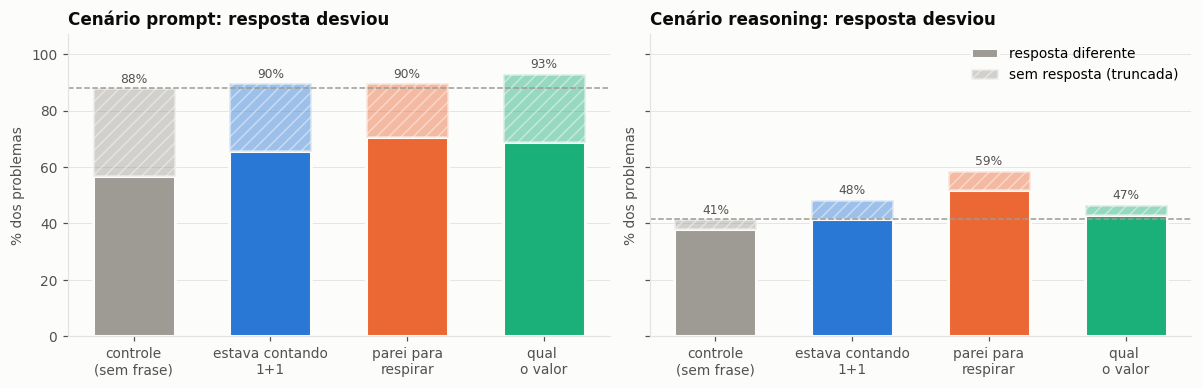

In [5]:
from scipy.stats import fisher_exact

clean = g[g.scenario == "clean"].set_index("instance_id")
g["clean_pred"] = g.instance_id.map(clean.pred_cents)
g["clean_correct"] = g.instance_id.map(clean.correct)
valid = g[g.pred_cents.notna() & g.clean_pred.notna()].copy()
valid["changed"] = valid.pred_cents != valid.clean_pred

# Desvio = resposta diferente OU nenhuma resposta (ex.: geração truncada em loop)
comp = g[g.clean_pred.notna() & (g.condition != "clean")].copy()
comp["desviou"] = comp.pred_cents.isna() | (comp.pred_cents != comp.clean_pred)

order = (["control"] + [f"prompt:{k}" for k in DKEYS]
         + ["reasoning:control"] + [f"reasoning:{k}" for k in DKEYS])
beh = comp.groupby("condition").agg(
    n=("desviou", "size"),
    sem_resposta=("pred_cents", lambda s: s.isna().sum()),
    mudou=("pred_cents", lambda s: 0),
    desviou=("desviou", "sum"),
    acuracia=("correct", "mean"),
).reindex(order)
beh["mudou"] = valid[valid.condition != "clean"].groupby("condition").changed.sum().reindex(order)
beh["taxa_desvio"] = beh.desviou / beh.n
for cond in order:
    ctrl = "control" if cond.startswith(("prompt", "control")) else "reasoning:control"
    if cond != ctrl:
        a, c = beh.loc[cond], beh.loc[ctrl]
        beh.loc[cond, "p_vs_controle"] = fisher_exact([[a.desviou, a.n - a.desviou],
                                                       [c.desviou, c.n - c.desviou]])[1]
beh.loc["clean", ["n", "sem_resposta", "mudou", "desviou", "acuracia", "taxa_desvio"]] = \
    [len(clean), clean.pred_cents.isna().sum(), 0, 0, clean.correct.mean(), 0.0]
display(beh.style.format({"taxa_desvio": "{:.1%}", "acuracia": "{:.1%}", "p_vs_controle": "{:.3f}",
                          "n": "{:.0f}", "sem_resposta": "{:.0f}", "mudou": "{:.0f}", "desviou": "{:.0f}"},
                         na_rep="—"))
print("desviou = resposta diferente da resposta sem frase, ou sem resposta final (truncada);"
      " p = teste exato de Fisher contra o controle do mesmo cenário")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, scen, ctrl in zip(axes, ["prompt", "reasoning"], ["control", "reasoning:control"]):
    rows = [ctrl] + [f"{scen}:{k}" for k in DKEYS]
    x = np.arange(len(rows))
    changed = beh.loc[rows, "mudou"].values / beh.loc[rows, "n"].values * 100
    failed = beh.loc[rows, "sem_resposta"].values / beh.loc[rows, "n"].values * 100
    colors = [CONTROL_COLOR] + [DCOLORS[k] for k in DKEYS]
    ax.bar(x, changed, color=colors, width=0.6, edgecolor=SURF, linewidth=2, label="resposta diferente")
    ax.bar(x, failed, bottom=changed, color=colors, width=0.6, edgecolor=SURF, linewidth=2,
           hatch="///", alpha=0.45, label="sem resposta (truncada)")
    for xi, tot in zip(x, changed + failed):
        ax.annotate(f"{tot:.0f}%", (xi, tot), ha="center", va="bottom", fontsize=8, color=INK2,
                    xytext=(0, 2), textcoords="offset points")
    ax.axhline(changed[0] + failed[0], color=CONTROL_COLOR, linestyle="--", linewidth=1)
    ax.set_xticks(x, ["controle\n(sem frase)"] + [k.replace("_", " ").replace(" 1+1", "\n1+1")
                                                  .replace("para ", "para\n").replace("o valor", "\no valor")
                                                  for k in DKEYS])
    ax.set_ylim(0, max(beh.taxa_desvio.max() * 100 * 1.15, 10))
    ax.set_title(f"Cenário {scen}: resposta desviou")
    ax.set_ylabel("% dos problemas")
    ax.grid(axis="x", visible=False)
axes[1].legend(loc="upper right")
fig.tight_layout()

In [6]:
# Direção da mudança: o distrator estraga acertos ou conserta erros?
def transitions(df):
    return pd.Series({
        "acerto→erro": ((df.clean_correct) & (~df.correct)).sum(),
        "erro→acerto": ((~df.clean_correct.astype(bool)) & (df.correct)).sum(),
        "erro→outro erro": ((~df.clean_correct.astype(bool)) & (~df.correct) & df.changed).sum(),
    })
valid.groupby("condition").apply(transitions, include_groups=False).reindex([c for c in order])

,acerto→erro,erro→acerto,erro→outro erro
condition,,,
control,5,1,27
prompt:estava_contando_1+1,3,6,29
prompt:parei_para_respirar,5,4,32
prompt:qual_o_valor,3,3,34
reasoning:control,0,2,20
reasoning:estava_contando_1+1,1,4,19
reasoning:parei_para_respirar,1,5,24
reasoning:qual_o_valor,2,3,20


**Como ler:** uma frase irrelevante só tem efeito real se a taxa de mudança
ficar **acima do controle** do mesmo cenário. Com decodificação gulosa em lotes,
parte das mudanças é ruído numérico: basta um token diferente para o raciocínio
seguir outro caminho. Se o controle do cenário *prompt* já muda muitas
respostas, a resposta final desses problemas é **instável por si só**, e o
efeito comportamental das frases não pode ser separado do ruído. As seções
seguintes medem o efeito interno, que não tem esse problema.

## 3. Captura das ativações

Uma passada *teacher-forced* por condição (~0,5 s cada). Os resumos ficam em
`captures/<problema>.pt` e também são reaproveitados.

**Referência de ruído numérico (`clean_padded`):** o mesmo texto limpo,
reprocessado com 8 tokens de padding mascarados à esquerda. O modelo vê
exatamente o mesmo texto; só muda a forma dos tensores, o mesmo tipo de
diferença que a geração em lotes introduz. Nos gráficos ela aparece como uma
linha cinza tracejada: **só o que fica acima dela é efeito da frase**.

In [7]:
E.run_capture(model, tok, gens, DISTRACTORS, CAP_DIR, prompt_mode=PROMPT_MODE)
recs = E.load_captures(CAP_DIR)
recs = [r for r in recs if r["instance_id"] in {s["instance_id"] for s in sample}]
CONDS = [c for c in ["clean", "clean_padded"] + [f"{s}:{k}" for s in ("prompt", "reasoning") for k in DKEYS]
         if all(c in r["conditions"] for r in recs)]
print(f"{len(recs)} problemas capturados | condições: {CONDS}")
print("Exemplo de resposta lida:", recs[0]["answer"], recs[0]["answer_tokens"])

capture:   0%|          | 0/90 [00:00<?, ?it/s]

capture:   1%|          | 1/90 [00:14<21:17, 14.35s/it]

capture:   2%|▏         | 2/90 [00:31<23:06, 15.76s/it]

capture:   3%|▎         | 3/90 [00:45<21:53, 15.10s/it]

capture:   4%|▍         | 4/90 [01:02<23:00, 16.06s/it]

...

capture:  97%|█████████▋| 87/90 [17:10<00:24,  8.04s/it]

capture:  98%|█████████▊| 88/90 [17:30<00:19,  9.87s/it]

capture:  99%|█████████▉| 89/90 [17:49<00:11, 11.54s/it]

capture: 100%|██████████| 90/90 [17:49<00:00, 11.89s/it]

58 problemas capturados | condições: ['clean', 'clean_padded', 'prompt:estava_contando_1+1', 'prompt:parei_para_respirar', 'prompt:qual_o_valor', 'reasoning:estava_contando_1+1', 'reasoning:parei_para_respirar', 'reasoning:qual_o_valor']
Exemplo de resposta lida: 1225 ['122', '5']


In [8]:
def per_layer(metric):
    # DataFrame (condição, camada) -> média e erro padrão entre problemas
    rows = []
    for r in recs:
        for cond, m in r["compare"].items():
            for layer, v in enumerate(m[metric]):
                rows.append({"condition": cond, "layer": layer, "value": float(v), "instance_id": r["instance_id"]})
    df = pd.DataFrame(rows)
    return df.groupby(["condition", "layer"]).value.agg(["mean", "sem"]).reset_index()

def plot_scenarios(df, ylabel, title, layer_offset=0, ylim=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
    for ax, scen in zip(axes, ["prompt", "reasoning"]):
        shade_band(ax)
        for k in DKEYS:
            d = df[df.condition == f"{scen}:{k}"]
            x = d.layer + layer_offset
            ax.plot(x, d["mean"], color=DCOLORS[k], label=k.replace("_", " "))
            ax.fill_between(x, d["mean"] - d["sem"], d["mean"] + d["sem"], color=DCOLORS[k], alpha=0.15, linewidth=0)
        ref = df[df.condition == "clean_padded"]
        if len(ref):
            ax.plot(ref.layer + layer_offset, ref["mean"], color=CONTROL_COLOR, linestyle="--",
                    linewidth=1.5, label="ruído numérico (mesmo texto)")
        ax.set_title(f"{title}: cenário {scen}")
        ax.set_xlabel("camada")
        ax.set_ylabel(ylabel)
        if ylim:
            ax.set_ylim(*ylim)
    axes[0].legend(loc="best")
    fig.tight_layout()
    return fig

## 4. Fluxo residual: quanto a frase desloca a representação

Distância relativa ‖h_com − h_sem‖ / ‖h_sem‖ do residual nas posições que
produzem a resposta, depois de cada camada. Zero = a frase não mudou nada
naquela camada. A faixa colorida em volta da linha é o erro padrão entre
problemas.

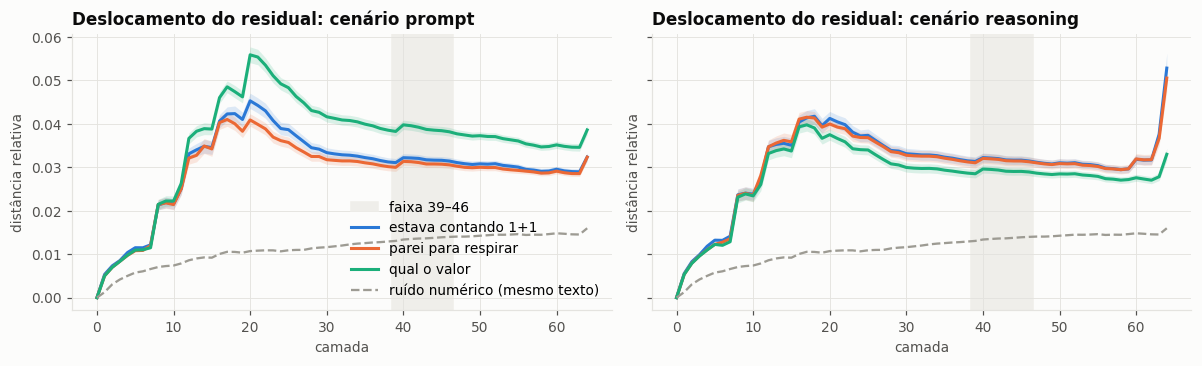

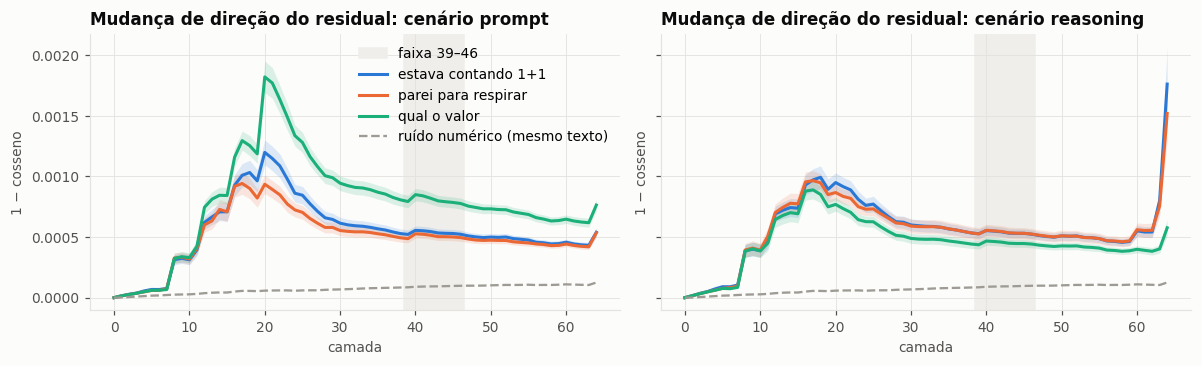

In [9]:
res = per_layer("resid_rel_l2")
plot_scenarios(res, "distância relativa", "Deslocamento do residual")
cos = per_layer("resid_cos")
cos["mean"] = 1 - cos["mean"]
plot_scenarios(cos, "1 − cosseno", "Mudança de direção do residual");

In [10]:
# Onde o deslocamento é máximo, por condição
peak = res.loc[res.groupby("condition")["mean"].idxmax()].set_index("condition")[["layer", "mean"]]
peak.columns = ["camada de pico", "distância no pico"]
band = res[res.layer.between(*BAND)].groupby("condition")["mean"].mean().rename(f"média {BAND[0]}–{BAND[1]}")
final = res[res.layer == N_LAYERS].set_index("condition")["mean"].rename("na última camada")
pd.concat([peak, band, final], axis=1).style.format({"distância no pico": "{:.3f}", f"média {BAND[0]}–{BAND[1]}": "{:.3f}", "na última camada": "{:.3f}"})

,camada de pico,distância no pico,média 39–46,na última camada
condition,,,,
clean_padded,64,0.016,0.014,0.016
prompt:estava_contando_1+1,20,0.045,0.032,0.032
prompt:parei_para_respirar,17,0.041,0.031,0.032
prompt:qual_o_valor,20,0.056,0.039,0.039
reasoning:estava_contando_1+1,64,0.053,0.032,0.053
reasoning:parei_para_respirar,64,0.051,0.032,0.051
reasoning:qual_o_valor,17,0.040,0.029,0.033


## 5. Logit lens: em que camada a resposta aparece

Para cada camada, aplicamos a normalização final e o *unembedding* ao residual
e medimos a probabilidade dos dígitos da resposta. A curva mostra **como a
resposta vai sendo construída** ao longo da profundidade. Se a frase
atrapalha, a curva da condição com frase fica abaixo ou deslocada para a direita.

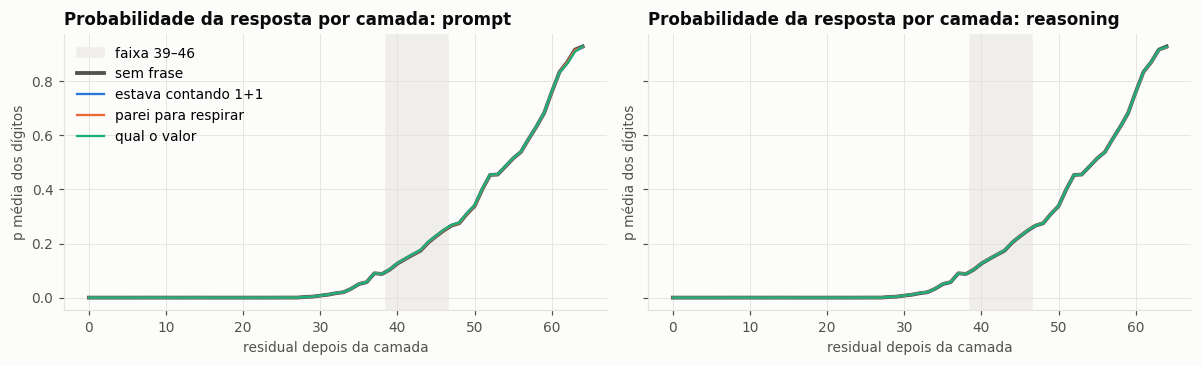

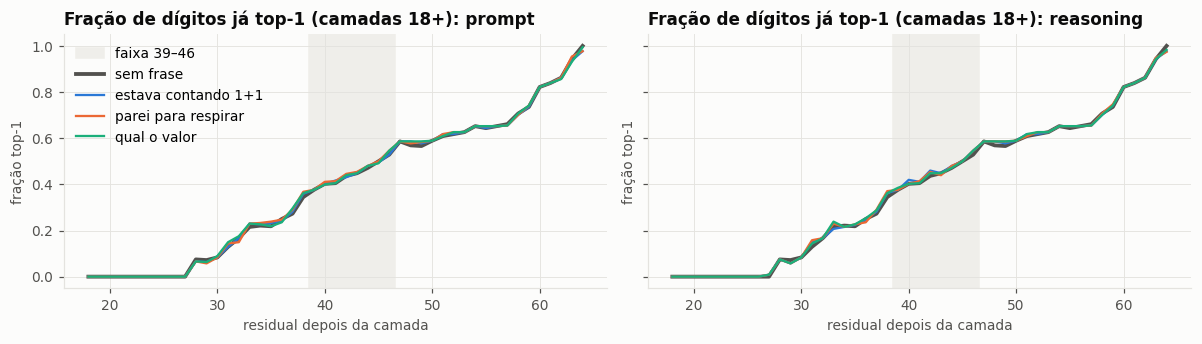

In [11]:
lens_rows = []
for r in recs:
    for cond in CONDS:
        s = r["conditions"][cond]
        p = np.exp(s["target_logp"]).mean(axis=1)            # média sobre os dígitos
        top1 = (s["target_rank"] == 0).mean(axis=1)
        for layer in range(len(p)):
            lens_rows.append({"instance_id": r["instance_id"], "condition": cond, "layer": layer,
                              "p_answer": p[layer], "top1_frac": top1[layer]})
lens = pd.DataFrame(lens_rows)
lm = lens.groupby(["condition", "layer"]).agg(p=("p_answer", "mean"), top1=("top1_frac", "mean")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    shade_band(ax)
    d = lm[lm.condition == "clean"]
    ax.plot(d.layer, d.p, color=CLEAN_COLOR, linewidth=2.5, label="sem frase")
    for k in DKEYS:
        d = lm[lm.condition == f"{scen}:{k}"]
        ax.plot(d.layer, d.p, color=DCOLORS[k], linewidth=1.5, label=k.replace("_", " "))
    ax.set_title(f"Probabilidade da resposta por camada: {scen}")
    ax.set_xlabel("residual depois da camada")
    ax.set_ylabel("p média dos dígitos")
axes[0].legend(loc="upper left")
fig.tight_layout()

# Zoom nas camadas finais, onde as curvas se separam
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    shade_band(ax)
    for cond, color, lw in [("clean", CLEAN_COLOR, 2.5)] + [(f"{scen}:{k}", DCOLORS[k], 1.5) for k in DKEYS]:
        d = lm[(lm.condition == cond) & (lm.layer >= 18)]
        ax.plot(d.layer, d.top1, color=color, linewidth=lw,
                label="sem frase" if cond == "clean" else cond.split(":")[1].replace("_", " "))
    ax.set_title(f"Fração de dígitos já top-1 (camadas 18+): {scen}")
    ax.set_xlabel("residual depois da camada")
    ax.set_ylabel("fração top-1")
axes[0].legend(loc="upper left")
fig.tight_layout()

### 5.1 Camada de convergência

Primeira camada a partir da qual **todos** os dígitos da resposta são a
predição top-1 até a última camada: é onde a resposta "fecha". Comparamos a
distribuição sem e com a frase, e a diferença problema a problema.

,mediana,média,% em 39–46,Δ médio vs sem frase,% problemas com Δ≠0
condition,,,,,
clean,59.5,54.74,18.97,0.00,0.00
clean_padded,59.5,54.69,17.24,-0.05,8.62
prompt:estava_contando_1+1,60.0,54.73,17.24,-0.07,15.52
prompt:parei_para_respirar,60.0,54.71,17.24,-0.09,17.24
prompt:qual_o_valor,59.0,54.58,18.97,0.00,18.97
reasoning:estava_contando_1+1,60.0,54.71,17.24,-0.07,18.97
reasoning:parei_para_respirar,62.0,55.07,13.79,-0.13,20.69
reasoning:qual_o_valor,61.0,54.82,13.79,-0.14,18.97


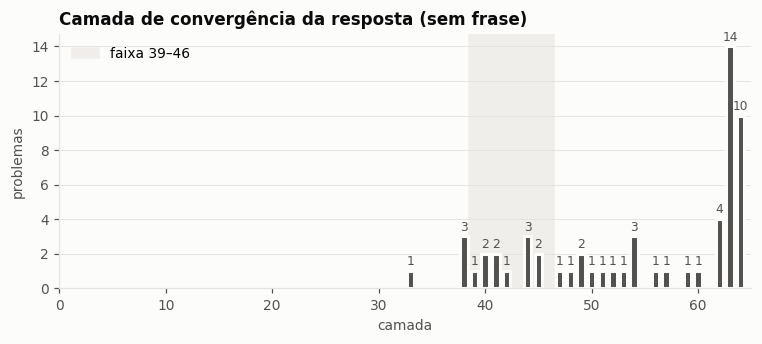

In [12]:
conv = pd.DataFrame([{"instance_id": r["instance_id"], "condition": c,
                      "conv": r["conditions"][c]["convergence_layer"]}
                     for r in recs for c in CONDS])
wide = conv.pivot(index="instance_id", columns="condition", values="conv")
summary = pd.DataFrame({
    "mediana": wide.median(),
    "média": wide.mean(),
    f"% em {BAND[0]}–{BAND[1]}": wide.apply(lambda s: s.between(*BAND).mean() * 100),
    "Δ médio vs sem frase": wide.sub(wide["clean"], axis=0).mean(),
    "% problemas com Δ≠0": wide.sub(wide["clean"], axis=0).ne(0).mean() * 100,
}).reindex(CONDS)
display(summary.round(2))

fig, ax = plt.subplots(figsize=(7, 3.2))
shade_band(ax)
vc = wide["clean"].value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=CLEAN_COLOR, width=0.7, edgecolor=SURF, linewidth=2)
bar_labels(ax, bars)
ax.set_title("Camada de convergência da resposta (sem frase)")
ax.set_xlabel("camada")
ax.set_ylabel("problemas")
ax.set_xlim(0, N_LAYERS + 1)
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()

### 5.2 A resposta correta camada a camada

Até aqui lemos a resposta **que o modelo deu**. Agora lemos a **resposta
correta** (o gabarito): o raciocínio de cada condição é reapresentado e, no
lugar da resposta do modelo, colocamos o valor certo.

**Ponto de decisão:** o primeiro dígito em que a resposta do modelo e o
gabarito divergem (ex.: gabarito $1,**2**45 × modelo $1,**3**65, 3º token).
Até ali o contexto é idêntico, então é nessa posição que o modelo "escolhe"
errado. Nela medimos, camada a camada:
- **p(correto)** e **rank(correto)**: probabilidade e posição do dígito certo
  (rank 0 = seria escolhido);
- **p(escolhido)**: probabilidade do dígito que o modelo de fato escolheu;
- o **top-1** de cada camada.

Nos problemas que o modelo acerta não há ponto de decisão; neles usamos o
primeiro dígito.

In [13]:
E.run_gold_capture(model, tok, gens, DISTRACTORS, CAP_DIR, prompt_mode=PROMPT_MODE)
recs = [r for r in E.load_captures(CAP_DIR) if r["instance_id"] in {s["instance_id"] for s in sample}]
GCONDS = [c for c in CONDS if all(c in r["gold"]["conditions"] for r in recs)]

def dec_pos(r):
    j = r["gold"]["divergence"]
    return 0 if j is None else j

# Tabela longa: problema × condição × camada, no ponto de decisão
drows = []
for r in recs:
    G, j = r["gold"], dec_pos(r)
    for cond in GCONDS:
        s = G["conditions"][cond]
        for layer in range(N_LAYERS + 1):
            drows.append({"instance_id": r["instance_id"], "condition": cond, "layer": layer,
                          "rank_gold": int(s["target_rank"][layer, j]),
                          "p_gold": float(np.exp(s["target_logp"][layer, j])),
                          "p_pred": float(np.exp(s["alt_logp"][layer, j])),
                          "acertou": G["divergence"] is None})
dec = pd.DataFrame(drows)
n_ok = sum(r["gold"]["divergence"] is None for r in recs)
print(f"{len(recs)} problemas | o modelo acerta {n_ok} (sem frase, raciocínio reapresentado) | "
      f"{len(recs) - n_ok} têm ponto de decisão")

gold capture:   0%|          | 0/58 [00:00<?, ?it/s]

gold capture:   2%|▏         | 1/58 [00:14<13:30, 14.22s/it]

gold capture:   3%|▎         | 2/58 [00:30<14:36, 15.66s/it]

gold capture:   5%|▌         | 3/58 [00:45<13:46, 15.02s/it]

gold capture:   7%|▋         | 4/58 [01:02<14:24, 16.00s/it]

...

gold capture:  97%|█████████▋| 56/58 [17:09<00:39, 19.56s/it]

gold capture:  98%|█████████▊| 57/58 [17:30<00:19, 19.76s/it]

gold capture: 100%|██████████| 58/58 [17:49<00:00, 19.64s/it]

gold capture: 100%|██████████| 58/58 [17:49<00:00, 18.44s/it]

58 problemas | o modelo acerta 6 (sem frase, raciocínio reapresentado) | 52 têm ponto de decisão


**Resposta selecionada × gabarito, por problema.** As respostas vêm da
geração livre de cada condição. O *rank final* é a posição do dígito correto,
no ponto de decisão, na última camada: 0 = seria escolhido, 1 = segundo
colocado etc.

In [14]:
ans = valid.pivot_table(index="instance_id", columns="condition", values="pred_cents", aggfunc="first") / 100
show_conds = ["clean", "control"] + [f"{sc}:{DKEYS[1]}" for sc in ("prompt", "reasoning")]
final = dec[dec.layer == N_LAYERS].pivot(index="instance_id", columns="condition", values="rank_gold")
overview = []
for r in recs:
    G, j = r["gold"], r["gold"]["divergence"]
    row = {"problema": r["instance_id"], "gabarito": f"${G['answer']}"}
    for c in show_conds:
        v = ans.loc[r["instance_id"]].get(c, np.nan) if r["instance_id"] in ans.index else np.nan
        row[f"resposta {c}"] = "—" if pd.isna(v) else f"${v:,.0f}"
    row["ponto de decisão"] = ("acertou" if j is None else
                               f"token {j + 1}: certo {G['tokens'][j] if j < len(G['tokens']) else '∅'!r}"
                               f" × escolhido {G['alt_tokens'][j]!r}")
    for c in ["clean", "clean_padded"] + [f"{sc}:{DKEYS[1]}" for sc in ("prompt", "reasoning")]:
        row[f"rank final {c}"] = int(final.loc[r["instance_id"], c])
    overview.append(row)
pd.DataFrame(overview).set_index("problema")

,gabarito,resposta clean,resposta control,resposta prompt:parei_para_respirar,resposta reasoning:parei_para_respirar,ponto de decisão,rank final clean,rank final clean_padded,rank final prompt:parei_para_respirar,rank final reasoning:parei_para_respirar
problema,,,,,,,,,,
c0_000,$1245,"$1,225","$1,405","$1,145","$1,255",token 1: certo '124' × escolhido '122',13,13,13,12
c0_003,"$1,513","$1,373","$1,373","$1,728","$1,373",token 3: certo '513' × escolhido '373',308,302,301,315
c0_004,$1434,"$1,434","$1,434","$1,384","$1,434",acertou,0,0,0,0
c0_011,"$1,203","$1,208","$1,208","$1,208","$1,208",token 3: certo '203' × escolhido '208',20,21,19,16
c0_013,$1097,"$1,317","$1,167","$1,217","$1,317",token 1: certo '109' × escolhido '131',6020,5721,5445,5721
c0_014,$1317,"$1,492","$1,392","$1,492",—,token 1: certo '131' × escolhido '149',325,320,318,315
c0_017,"$1,321","$1,481","$1,481","$1,181","$1,321",token 3: certo '321' × escolhido '481',3773,3800,3786,3570
c0_027,$1277,"$1,787","$1,417","$1,417",—,token 1: certo '127' × escolhido '178',99,102,103,101
c0_028,$970,"$1,110","$1,260",—,"$1,260",token 1: certo '970' × escolhido '1',33839,34210,33101,33158


,problemas,rank mediano,% rank 0 (escolheria certo),% top-2,% top-5,p(correto) média,p(escolhido) média
condition,,,,,,,
clean,52,84.0,0.0,0.0,5.769,0.0,0.898
clean_padded,52,82.5,0.0,0.0,5.769,0.0,0.897
prompt:estava_contando_1+1,52,84.0,0.0,0.0,5.769,0.0,0.887
prompt:parei_para_respirar,52,84.5,0.0,0.0,5.769,0.0,0.889
prompt:qual_o_valor,52,84.5,0.0,0.0,5.769,0.0,0.902
reasoning:estava_contando_1+1,52,85.5,0.0,0.0,5.769,0.0,0.885
reasoning:parei_para_respirar,52,84.0,0.0,0.0,5.769,0.0,0.887
reasoning:qual_o_valor,52,85.0,0.0,0.0,5.769,0.0,0.889


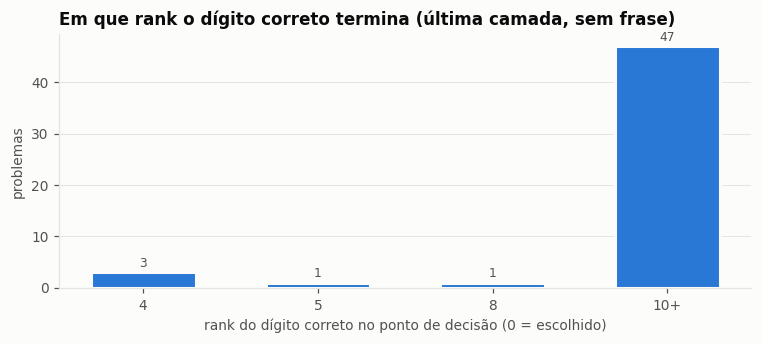

In [15]:
# Resumo por condição, na última camada e no ponto de decisão (só problemas com erro)
last = dec[(dec.layer == N_LAYERS) & (~dec.acertou)]
summary_gold = last.groupby("condition").agg(
    problemas=("rank_gold", "size"),
    rank_mediano=("rank_gold", "median"),
    pct_rank0=("rank_gold", lambda s: (s == 0).mean() * 100),
    pct_top2=("rank_gold", lambda s: (s <= 1).mean() * 100),
    pct_top5=("rank_gold", lambda s: (s <= 4).mean() * 100),
    p_correto=("p_gold", "mean"),
    p_escolhido=("p_pred", "mean"),
).reindex(GCONDS)
summary_gold.columns = ["problemas", "rank mediano", "% rank 0 (escolheria certo)", "% top-2", "% top-5",
                        "p(correto) média", "p(escolhido) média"]
display(summary_gold.round(3))

# Distribuição do rank final do dígito correto, sem frase
fig, ax = plt.subplots(figsize=(7, 3.2))
vc = last[last.condition == "clean"].rank_gold.clip(upper=10).value_counts().sort_index()
bars = ax.bar(vc.index.astype(int).astype(str).str.replace("10", "10+"), vc.values, color="#2a78d6",
              width=0.6, edgecolor=SURF, linewidth=2)
bar_labels(ax, bars)
ax.set_title("Em que rank o dígito correto termina (última camada, sem frase)")
ax.set_xlabel("rank do dígito correto no ponto de decisão (0 = escolhido)")
ax.set_ylabel("problemas")
ax.grid(axis="x", visible=False)
fig.tight_layout()

**Probabilidade e rank do dígito correto ao longo das camadas.** À esquerda,
p(correto) × p(escolhido) sem frase: a camada em que a curva do escolhido
passa a do correto é onde a decisão errada se forma. À direita, o rank mediano
do dígito correto (escala log) em cada condição.

Camada em que o dígito escolhido (errado) passa o correto e não perde mais a frente:


,mediana,média,% em 39–46
condition,,,
clean,27.0,24.3,0.0
clean_padded,27.0,24.3,0.0
prompt:estava_contando_1+1,27.0,24.3,0.0
prompt:parei_para_respirar,26.5,24.2,0.0
prompt:qual_o_valor,27.0,24.3,0.0
reasoning:estava_contando_1+1,27.0,24.3,0.0
reasoning:parei_para_respirar,26.5,24.2,0.0
reasoning:qual_o_valor,27.0,24.4,0.0


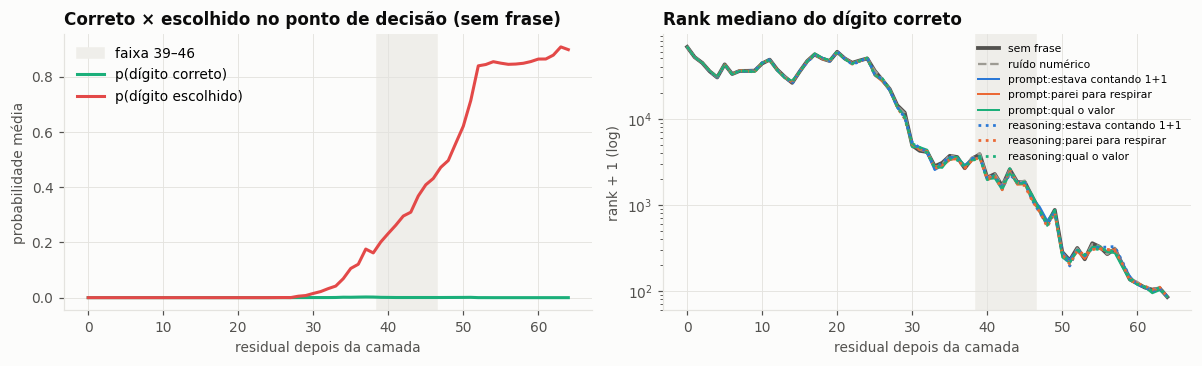

In [16]:
err = dec[~dec.acertou]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
shade_band(ax)
m = err[err.condition == "clean"].groupby("layer")[["p_gold", "p_pred"]].mean()
ax.plot(m.index, m.p_gold, color="#1baf7a", label="p(dígito correto)")
ax.plot(m.index, m.p_pred, color="#e34948", label="p(dígito escolhido)")
ax.set_title("Correto × escolhido no ponto de decisão (sem frase)")
ax.set_xlabel("residual depois da camada")
ax.set_ylabel("probabilidade média")
ax.legend(loc="upper left")

ax = axes[1]
shade_band(ax, label=False)
for cond, color, ls, lw in ([("clean", CLEAN_COLOR, "-", 2.5), ("clean_padded", CONTROL_COLOR, "--", 1.5)]
                            + [(f"prompt:{k}", DCOLORS[k], "-", 1.3) for k in DKEYS]
                            + [(f"reasoning:{k}", DCOLORS[k], ":", 1.8) for k in DKEYS]):
    if cond not in GCONDS:
        continue
    med = err[err.condition == cond].groupby("layer").rank_gold.median()
    ax.plot(med.index, med.values + 1, color=color, linestyle=ls, linewidth=lw,
            label={"clean": "sem frase", "clean_padded": "ruído numérico"}.get(cond, cond.replace("_", " ")))
ax.set_yscale("log")
ax.set_title("Rank mediano do dígito correto")
ax.set_xlabel("residual depois da camada")
ax.set_ylabel("rank + 1 (log)")
ax.legend(loc="upper right", fontsize=7, ncol=1)
fig.tight_layout()

# Camada em que o escolhido passa o correto de vez
def crossover(g):
    ahead = (g.sort_values("layer").p_pred > g.sort_values("layer").p_gold).values
    if not ahead[-1]:
        return np.nan
    k = len(ahead) - 1
    while k > 0 and ahead[k - 1]:
        k -= 1
    return k
cross = err.groupby(["condition", "instance_id"]).apply(crossover, include_groups=False).unstack(0)
print("Camada em que o dígito escolhido (errado) passa o correto e não perde mais a frente:")
display(pd.DataFrame({"mediana": cross.median(), "média": cross.mean(),
                      f"% em {BAND[0]}–{BAND[1]}": cross.apply(lambda s: s.between(*BAND).mean() * 100)})
        .reindex(GCONDS).round(1))

**Camada a camada, para um problema.** Para cada condição: o top-1 da camada
(com probabilidade), p(correto), rank(correto) e p(escolhido), no ponto de
decisão. Mostramos o problema em que o dígito correto chegou mais perto de
ser escolhido sem frase.

In [17]:
def show_layers(rec, conds, layers=range(16, N_LAYERS + 1)):
    G, j = rec["gold"], dec_pos(rec)
    print(f"Problema {rec['instance_id']} | gabarito ${G['answer']} | resposta do modelo ${rec['answer']} | "
          f"ponto de decisão: token {j + 1} (correto {G['tokens'][j]!r} × escolhido {G['alt_tokens'][j]!r})")
    cols = {}
    for cond in conds:
        s = G["conditions"][cond]
        name = {"clean": "sem frase", "clean_padded": "ruído numérico"}.get(cond, cond)
        cols[(name, "top-1")] = [f"{tok.decode([int(s['top_ids'][l, j, 0])])!r} {np.exp(s['top_logp'][l, j, 0]):.2f}"
                                 for l in layers]
        cols[(name, "p(correto)")] = [np.exp(s["target_logp"][l, j]) for l in layers]
        cols[(name, "rank")] = [int(s["target_rank"][l, j]) for l in layers]
        cols[(name, "p(escolhido)")] = [np.exp(s["alt_logp"][l, j]) for l in layers]
    df = pd.DataFrame(cols, index=[f"camada {l}" for l in layers])
    fmt = {c: "{:.3f}" for c in df.columns if c[1] in ("p(correto)", "p(escolhido)")}
    return df.style.format(fmt).background_gradient(
        subset=[c for c in df.columns if c[1] == "p(correto)"], cmap="Greens", vmin=0, vmax=1)

with_err = [r for r in recs if r["gold"]["divergence"] is not None]
if with_err:
    closest = min(with_err, key=lambda r: (int(final.loc[r["instance_id"], "clean"]),
                                          -float(np.exp(r["gold"]["conditions"]["clean"]["target_logp"][-1, dec_pos(r)]))))
    display(show_layers(closest, ["clean", "clean_padded", f"prompt:{DKEYS[1]}", f"reasoning:{DKEYS[1]}"]))

Problema c0_086 | gabarito $1392 | resposta do modelo $1497 | ponto de decisão: token 1 (correto '139' × escolhido '149')


In [18]:
# Outro exemplo: o problema em que a frase mais mudou a probabilidade do dígito correto
def gold_shift(r, cond):
    s0, s1 = r["gold"]["conditions"]["clean"], r["gold"]["conditions"][cond]
    j = dec_pos(r)
    return abs(np.exp(s1["target_logp"][-1, j]) - np.exp(s0["target_logp"][-1, j]))

if with_err:
    cand = [(gold_shift(r, c), r, c) for r in with_err for c in GCONDS if c.startswith(("prompt", "reasoning"))]
    _, most, cond = max(cand, key=lambda t: t[0])
    print(f"Maior mudança de p(correto) na última camada: condição {cond}")
    display(show_layers(most, ["clean", "clean_padded", cond]))

Maior mudança de p(correto) na última camada: condição reasoning:estava_contando_1+1
Problema c0_086 | gabarito $1392 | resposta do modelo $1497 | ponto de decisão: token 1 (correto '139' × escolhido '149')


## 6. Camadas amplificadoras

**Atribuição direta ao logit (DLA):** quanto a saída da atenção e da MLP de
cada camada empurra o logit do dígito correto, em relação ao logit médio do
vocabulário. As camadas com maior DLA são as que **amplificam** a resposta.
Primeiro a condição sem frase; depois, quanto a frase muda cada camada.

Camadas amplificadoras (maior DLA total, sem frase):


,camada,attn,mlp,total
0,63,1.48,5.01,6.50
1,64,1.15,3.38,4.53
2,62,1.28,2.93,4.21
3,61,0.98,2.30,3.28
4,59,0.78,1.29,2.06
5,56,-0.02,1.39,1.38
6,57,0.34,0.97,1.31
7,52,0.68,0.51,1.19


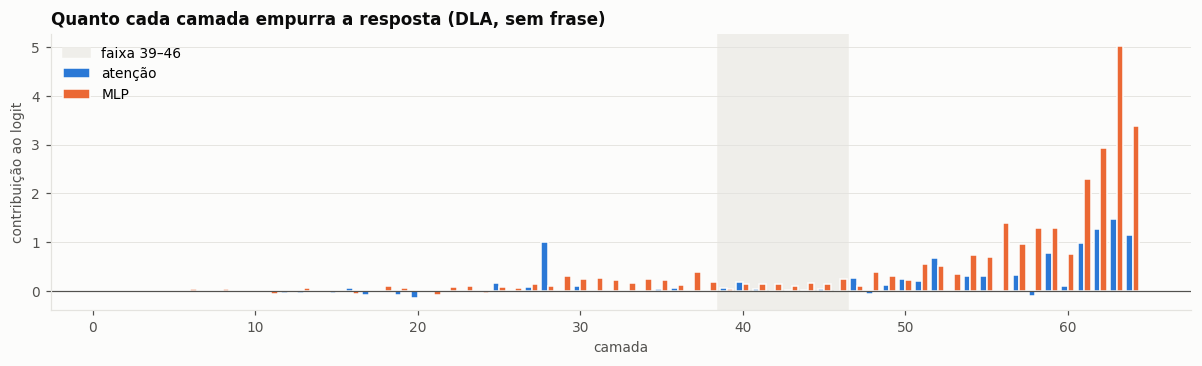

In [19]:
dla_rows = []
for r in recs:
    for cond in CONDS:
        s = r["conditions"][cond]
        for layer in range(N_LAYERS):
            dla_rows.append({"instance_id": r["instance_id"], "condition": cond, "layer": layer + 1,
                             "attn": s["dla_attn"][layer].mean(), "mlp": s["dla_mlp"][layer].mean()})
dla = pd.DataFrame(dla_rows)
dla["total"] = dla.attn + dla.mlp
dm = dla.groupby(["condition", "layer"])[["attn", "mlp", "total"]].mean().reset_index()

d = dm[dm.condition == "clean"]
fig, ax = plt.subplots(figsize=(11, 3.4))
shade_band(ax)
w = 0.4
ax.bar(d.layer - w / 2, d.attn, width=w, color="#2a78d6", label="atenção", edgecolor=SURF, linewidth=1)
ax.bar(d.layer + w / 2, d.mlp, width=w, color="#eb6834", label="MLP", edgecolor=SURF, linewidth=1)
ax.axhline(0, color=INK2, linewidth=0.8)
ax.set_title("Quanto cada camada empurra a resposta (DLA, sem frase)")
ax.set_xlabel("camada")
ax.set_ylabel("contribuição ao logit")
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()

top = d.nlargest(8, "total")[["layer", "attn", "mlp", "total"]].rename(columns={"layer": "camada"})
print("Camadas amplificadoras (maior DLA total, sem frase):")
display(top.round(2).reset_index(drop=True))

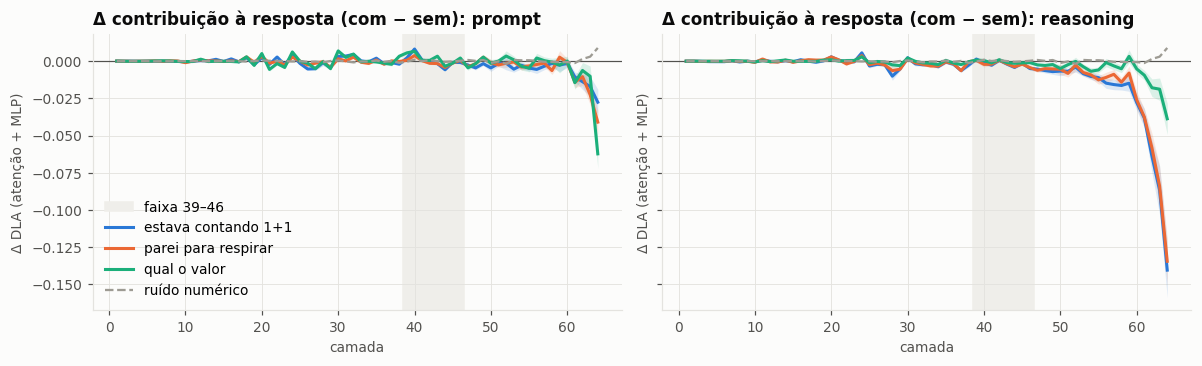

In [20]:
# Mudança da DLA causada pela frase: (com frase) − (sem frase), por camada
base = dla[dla.condition == "clean"].set_index(["instance_id", "layer"])[["attn", "mlp", "total"]]
delta_rows = []
for cond in CONDS[1:]:
    x = dla[dla.condition == cond].set_index(["instance_id", "layer"])[["attn", "mlp", "total"]]
    dd = (x - base).reset_index()
    dd["condition"] = cond
    delta_rows.append(dd)
ddla = pd.concat(delta_rows).groupby(["condition", "layer"])[["attn", "mlp", "total"]].agg(["mean", "sem"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    shade_band(ax)
    ax.axhline(0, color=INK2, linewidth=0.8)
    for k in DKEYS:
        s = ddla.loc[f"{scen}:{k}"]["total"]
        ax.plot(s.index, s["mean"], color=DCOLORS[k], label=k.replace("_", " "))
        ax.fill_between(s.index, s["mean"] - s["sem"], s["mean"] + s["sem"], color=DCOLORS[k], alpha=0.15, linewidth=0)
    if "clean_padded" in ddla.index.get_level_values(0):
        s = ddla.loc["clean_padded"]["total"]
        ax.plot(s.index, s["mean"], color=CONTROL_COLOR, linestyle="--", linewidth=1.5, label="ruído numérico")
    ax.set_title(f"Δ contribuição à resposta (com − sem): {scen}")
    ax.set_xlabel("camada")
    ax.set_ylabel("Δ DLA (atenção + MLP)")
axes[0].legend(loc="lower left")
fig.tight_layout()

**Como ler:** valores negativos significam que, com a frase, aquela camada
empurra **menos** a resposta correta. Se a frase atrapalha de verdade, a queda
se concentra nas camadas amplificadoras da tabela acima.

## 7. Neurônios da MLP

Para cada camada, na posição que produz o primeiro dígito da resposta:
- **sobreposição dos mais ativos**: Jaccard entre o 1% de neurônios de maior
  |ativação| sem e com a frase (123 de 12 288 no Qwen3-8B). 1 = os mesmos neurônios.
- **mudança relativa das ativações** da MLP: ‖a_com − a_sem‖ / ‖a_sem‖.
- **neurônios fortemente alterados**: quantos mudam mais de 3 desvios-padrão
  (desvio das ativações da própria camada, sem frase).

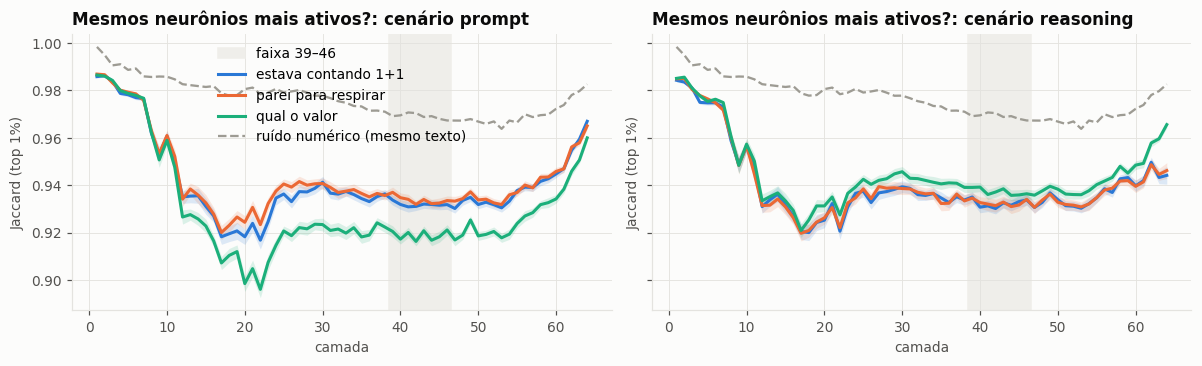

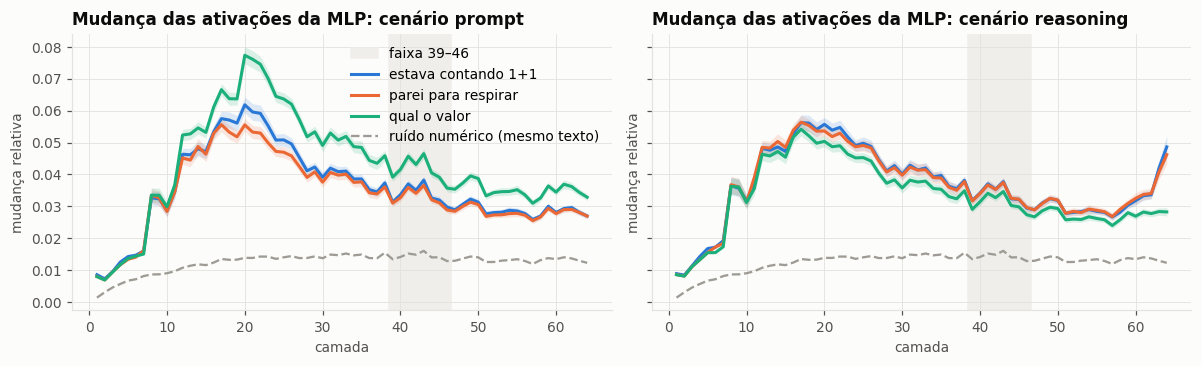

In [21]:
plot_scenarios(per_layer("neuron_jaccard"), "Jaccard (top 1%)", "Mesmos neurônios mais ativos?", layer_offset=1)
plot_scenarios(per_layer("mlp_rel_l2"), "mudança relativa", "Mudança das ativações da MLP", layer_offset=1);

Neurônios com maior |Δ ativação| médio (camada·neurônio):


,clean_padded,prompt:estava_contando_1+1,prompt:parei_para_respirar,prompt:qual_o_valor,reasoning:estava_contando_1+1,reasoning:parei_para_respirar,reasoning:qual_o_valor
0,L64·n11899,L64·n11899,L64·n11899,L64·n11899,L64·n11899,L64·n11899,L64·n11899
1,L64·n9594,L64·n9594,L64·n9594,L64·n9594,L64·n9594,L64·n9594,L64·n9594
2,L64·n17979,L64·n17979,L64·n17979,L64·n2337,L64·n19483,L64·n19483,L64·n17979
3,L64·n299,L64·n4691,L64·n4757,L64·n21169,L64·n15562,L64·n4757,L64·n4757
4,L64·n7072,L64·n21169,L64·n21203,L64·n13094,L64·n26783,L64·n26783,L64·n19483
5,L64·n4757,L64·n4757,L64·n4691,L64·n4757,L64·n10385,L64·n10385,L64·n21956
6,L64·n24282,L63·n21579,L63·n24221,L63·n24221,L64·n4757,L64·n17979,L64·n21169
7,L64·n2337,L64·n21203,L64·n299,L64·n22508,L64·n21956,L64·n27549,L64·n27549
8,L64·n21203,L63·n24221,L64·n21956,L64·n4691,L64·n7190,L64·n15562,L64·n21203
9,L64·n21956,L64·n7072,L64·n21169,L63·n21579,L64·n17979,L64·n21956,L63·n16279


Sobreposição dos 100 neurônios mais afetados entre condições:


,clean_padded,prompt:estava_contando_1+1,prompt:parei_para_respirar,prompt:qual_o_valor,reasoning:estava_contando_1+1,reasoning:parei_para_respirar,reasoning:qual_o_valor
clean_padded,100,81,84,79,63,64,77
prompt:estava_contando_1+1,81,100,88,79,64,65,80
prompt:parei_para_respirar,84,88,100,79,65,66,84
prompt:qual_o_valor,79,79,79,100,57,58,70
reasoning:estava_contando_1+1,63,64,65,57,100,95,76
reasoning:parei_para_respirar,64,65,66,58,95,100,77
reasoning:qual_o_valor,77,80,84,70,76,77,100


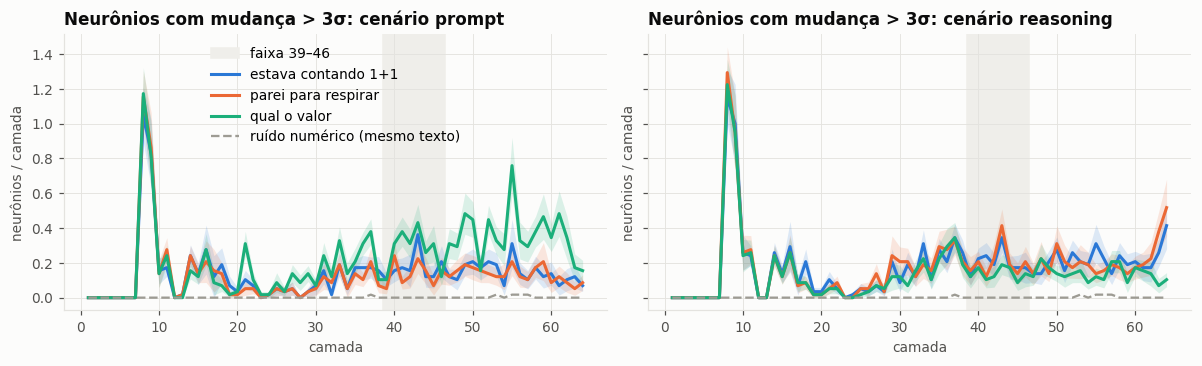

In [22]:
# Neurônios fortemente alterados (> 3σ) e neurônios afetados de forma consistente
strong_rows = []
mean_abs_delta = {c: torch.zeros(N_LAYERS, D_FF) for c in CONDS[1:]}
for r in recs:
    a0 = r["conditions"]["clean"]["mlp_act_pos0"].float()                 # [L, d_ff]
    sigma = a0.std(dim=1, keepdim=True)
    for cond in CONDS[1:]:
        delta = r["conditions"][cond]["mlp_act_pos0"].float() - a0
        mean_abs_delta[cond] += delta.abs() / len(recs)
        n_strong = (delta.abs() > 3 * sigma).sum(1)
        for layer, n in enumerate(n_strong.tolist()):
            strong_rows.append({"condition": cond, "layer": layer, "value": n})
strong = pd.DataFrame(strong_rows).groupby(["condition", "layer"]).value.agg(["mean", "sem"]).reset_index()
plot_scenarios(strong, "neurônios / camada", "Neurônios com mudança > 3σ", layer_offset=1)

# Top-20 neurônios mais afetados em média, por condição
tops = {}
for cond, m in mean_abs_delta.items():
    flat = m.flatten().topk(20)
    tops[cond] = [(int(i) // D_FF + 1, int(i) % D_FF) for i in flat.indices]
top_df = pd.DataFrame({c: [f"L{l}·n{n}" for l, n in v] for c, v in tops.items()})
print("Neurônios com maior |Δ ativação| médio (camada·neurônio):")
display(top_df.head(10))

# Os mesmos neurônios reagem a frases diferentes? (sobreposição dos top-100)
top100 = {c: set(m.flatten().topk(100).indices.tolist()) for c, m in mean_abs_delta.items()}
ov = pd.DataFrame([[len(top100[a] & top100[b]) for b in top100] for a in top100],
                  index=list(top100), columns=list(top100))
print("Sobreposição dos 100 neurônios mais afetados entre condições:")
display(ov)

Se os mesmos neurônios aparecem para frases e cenários diferentes, eles
respondem a *qualquer* interrupção irrelevante, não ao conteúdo específico da
frase. São candidatos a análise causal (ablação ou *patching*).

## 8. O que cada camada gera

Decodificação do residual pelo logit lens na posição que produz o **primeiro
dígito** da resposta, para um problema. A tabela mostra, camada a camada, o
token top-1 e sua probabilidade sem e com a frase. É o "fluxo residual" lido
em palavras.

In [23]:
def layer_table(rec, conds, layers=None):
    layers = layers if layers is not None else range(N_LAYERS + 1)
    out = {}
    for cond in conds:
        s = rec["conditions"][cond]
        col = []
        for layer in layers:
            toks = [tok.decode([int(t)]) for t in s["top_ids"][layer, 0]]
            ps = np.exp(s["top_logp"][layer, 0])
            col.append("  ".join(f"{t!r} {p:.2f}" for t, p in zip(toks, ps)))
        out[cond] = col
    return pd.DataFrame(out, index=[f"camada {l}" for l in layers])

# problema cujo residual mais mudou na faixa de referência
shift = {r["instance_id"]: np.mean([r["compare"][c]["resid_rel_l2"][BAND[0]:BAND[1] + 1].mean()
                                    for c in r["compare"]]) for r in recs}
example = max(recs, key=lambda r: shift[r["instance_id"]])
print(f"Problema {example['instance_id']} | resposta lida: ${example['answer']} | "
      f"primeiro token: {example['answer_tokens'][0]!r}")
with pd.option_context("display.max_colwidth", 60):
    display(layer_table(example, ["clean", f"prompt:{DKEYS[1]}", f"reasoning:{DKEYS[1]}"],
                        layers=list(range(0, N_LAYERS + 1, 2)) + ([N_LAYERS] if N_LAYERS % 2 else [])))

Problema c0_084 | resposta lida: $1,439 | primeiro token: '1'


,clean,prompt:parei_para_respirar,reasoning:parei_para_respirar
camada 0,'ching' 0.00 'Retention' 0.00 ' Wis' 0.00,'ching' 0.00 'Retention' 0.00 ' Wis' 0.00,'ching' 0.00 'Retention' 0.00 ' Wis' 0.00
camada 2,' steward' 0.00 ' exponentially' 0.00 'azor' 0.00,' steward' 0.00 ' exponentially' 0.00 'azor' 0.00,' steward' 0.00 ' exponentially' 0.00 'azor' 0.00
camada 4,' steward' 0.00 '921' 0.00 'ocks' 0.00,' steward' 0.00 '921' 0.00 'ocks' 0.00,' steward' 0.00 '921' 0.00 'ocks' 0.00
camada 6,' saved' 0.00 ' lucr' 0.00 'wg' 0.00,' saved' 0.00 ' lucr' 0.00 'wg' 0.00,' saved' 0.00 ' lucr' 0.00 'wg' 0.00
camada 8,' lucr' 0.01 ' CAT' 0.00 ' Hun' 0.00,' lucr' 0.01 ' CAT' 0.00 ' Hun' 0.00,' lucr' 0.01 ' CAT' 0.00 ' Hun' 0.00
camada 10,' lucr' 0.01 'ilter' 0.00 ' Luk' 0.00,' lucr' 0.01 'ilter' 0.00 ' Luk' 0.00,' lucr' 0.01 ' Luk' 0.00 'ilter' 0.00
camada 12,' Wick' 0.00 'izador' 0.00 'chg' 0.00,' Wick' 0.00 'izador' 0.00 'chg' 0.00,' Wick' 0.00 'izador' 0.00 'chg' 0.00
camada 14,'/pass' 0.00 ' requis' 0.00 'iban' 0.00,'/pass' 0.00 ' bloom' 0.00 'iban' 0.00,'/pass' 0.00 ' requis' 0.00 'iban' 0.00
camada 16,'lage' 0.01 'ackers' 0.01 ' Lup' 0.00,'lage' 0.02 'ackers' 0.01 ' Lup' 0.00,'lage' 0.01 'ackers' 0.01 ' Lup' 0.00
camada 18,' energ' 0.00 'oti' 0.00 ' zł' 0.00,' energ' 0.00 'oti' 0.00 ' zł' 0.00,'oti' 0.00 ' energ' 0.00 ' zł' 0.00


## 9. As ativações preveem o comportamento?

Se o deslocamento interno importa, os problemas em que a resposta **mudou** na
geração livre deveriam ter deslocamento maior na faixa de referência do que
os problemas em que não mudou.

n  deslocamento  jaccard
scenario  resposta                             
prompt    mudou      119         0.035    0.927
          não mudou   16         0.031    0.931
reasoning mudou       79         0.031    0.934
          não mudou   85         0.031    0.934

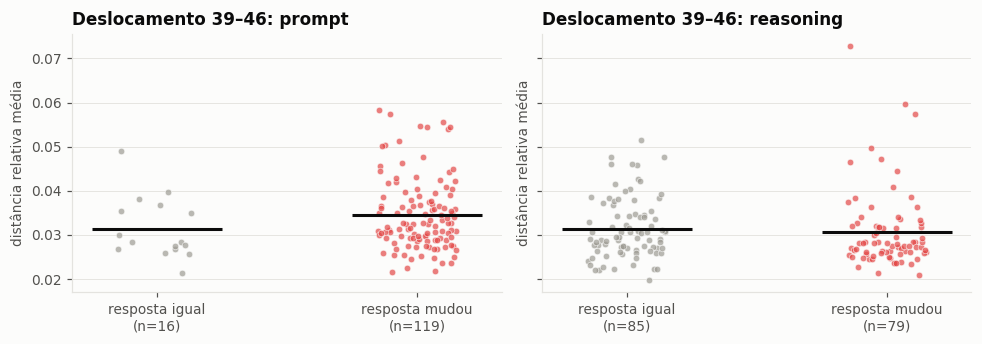

In [24]:
link = []
for r in recs:
    for cond, m in r["compare"].items():
        link.append({"instance_id": r["instance_id"], "condition": cond,
                     "shift_band": m["resid_rel_l2"][BAND[0]:BAND[1] + 1].mean(),
                     "jaccard_band": m["neuron_jaccard"][BAND[0] - 1:BAND[1]].mean()})
link = pd.DataFrame(link).merge(valid[["instance_id", "condition", "changed"]], on=["instance_id", "condition"])
link["scenario"] = link.condition.str.split(":").str[0]
link["resposta"] = link.changed.map({False: "não mudou", True: "mudou"})
display(link.groupby(["scenario", "resposta"]).agg(n=("shift_band", "size"),
                                                   deslocamento=("shift_band", "mean"),
                                                   jaccard=("jaccard_band", "mean")).round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, scen in zip(axes, ["prompt", "reasoning"]):
    d = link[link.scenario == scen]
    groups = [d[~d.changed].shift_band, d[d.changed].shift_band]
    for i, (vals, color) in enumerate(zip(groups, [CONTROL_COLOR, "#e34948"])):
        jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=18, color=color, alpha=0.7, edgecolor=SURF, linewidth=0.5)
        if len(vals):
            ax.hlines(vals.mean(), i - 0.25, i + 0.25, color=INK, linewidth=2)
    ax.set_xticks([0, 1], [f"resposta igual\n(n={len(groups[0])})", f"resposta mudou\n(n={len(groups[1])})"])
    ax.set_title(f"Deslocamento {BAND[0]}–{BAND[1]}: {scen}")
    ax.set_ylabel("distância relativa média")
    ax.grid(axis="x", visible=False)
fig.tight_layout()

## 10. Leitura e limitações

- **Comportamento × controle.** A taxa de mudança só indica sensibilidade real
  quando fica acima do controle do mesmo cenário (seção 2.1).
- **Teacher forcing.** As ativações são medidas reapresentando o raciocínio
  **limpo**. Assim elas isolam o efeito da frase sobre a *leitura* da resposta,
  mas não capturam o caso em que a frase desvia o raciocínio para outro
  caminho; esse caso aparece na geração livre (seção 2).
- **Logit lens** é uma leitura aproximada das camadas intermediárias:
  camadas iniciais não "falam" no espaço do vocabulário. A camada de
  convergência é uma medida relativa (com × sem frase), não absoluta.
- **Correlação, não causalidade.** Neurônios e camadas que mudam são
  candidatos; para provar papel causal, o próximo passo é *activation
  patching*: copiar o residual limpo para a condição com frase numa camada e
  ver se a resposta volta.
- **Modelo e amostra:** um modelo por execução (bf16), 90 problemas, uma seed.
- **Tokenização de números:** Qwen quebra números em um token por dígito;
  Llama 3 agrupa até 3 dígitos por token. As análises funcionam por token, então
  em Llama o "ponto de decisão" pode ser um bloco de dígitos.